<a href="https://colab.research.google.com/github/kk12102006/DAV/blob/main/LAB%20PROGRAM%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
data={
    "Student":["A","B","C","D","E","F",'G',"H","I","J","K","L","M","N","O","P","Q","R","S",'T'],
    "Mark":[45,50,42,59,67,5,46,71,48,53,51,67,61,50,68,100,95,57,55,49]

}
df=pd.DataFrame(data)
print(df)

   Student  Mark
0        A    45
1        B    50
2        C    42
3        D    59
4        E    67
5        F     5
6        G    46
7        H    71
8        I    48
9        J    53
10       K    51
11       L    67
12       M    61
13       N    50
14       O    68
15       P   100
16       Q    95
17       R    57
18       S    55
19       T    49


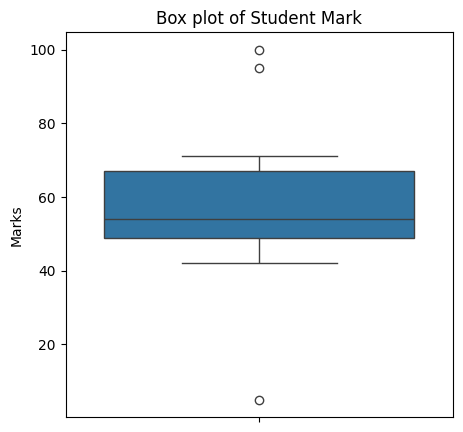

In [29]:
plt.figure(figsize=(5,5))
sns.boxplot(y=df["Mark"])
plt.title("Box plot of Student Mark")
plt.ylabel("Marks")
plt.show()

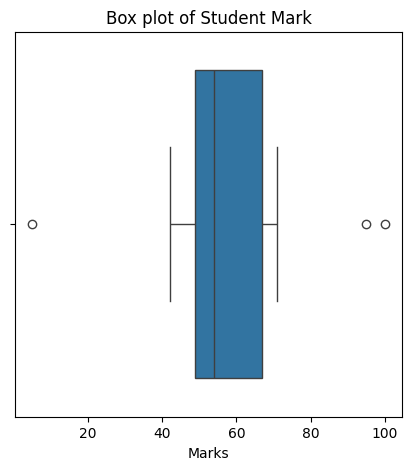

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(x=df["Mark"])
plt.title("Box plot of Student Mark")
plt.xlabel("Marks")
plt.show()

In [ ]:
Q1=df["Mark"].quantile(0.25)
Q3=df["Mark"].quantile(0.75)
print("Q1:",Q1)
print("Q3:",Q3)

Q1: 48.75
Q3: 67.0


In [ ]:
IQR=Q3-Q1
print("IQR:",IQR)

IQR: 18.25


In [ ]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print("Lower Limit:",lower_limit)
print("Upper Limit:",upper_limit)

Lower Limit: 21.375
Upper Limit: 94.375


In [ ]:
outlier_iqr=df[
    (df["Mark"]<lower_limit) | (df["Mark"]>upper_limit)
]
print("Outlier detected using IQR:\n",outlier_iqr)

Outlier detected using IQR:
    Student  Mark
5        F     5
15       P   100
16       Q    95


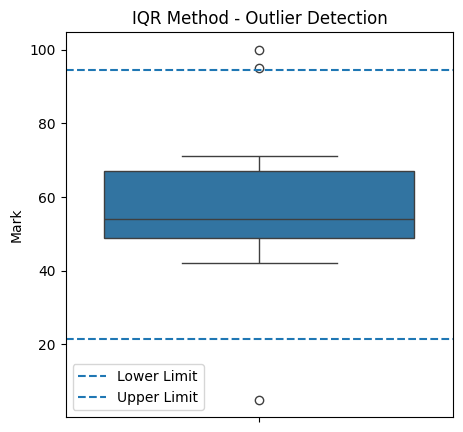

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(y=df["Mark"])
plt.axhline(lower_limit,linestyle="--",label="Lower Limit")
plt.axhline(upper_limit,linestyle="--",label="Upper Limit")
plt.title("IQR Method - Outlier Detection")
plt.legend()
plt.show()

In [ ]:
df["Marks_IQR_Capped"]=df["Mark"].clip(lower=lower_limit,upper=upper_limit)
print(df[["Mark","Marks_IQR_Capped"]])

    Mark  Marks_IQR_Capped
0     45            45.000
1     50            50.000
2     42            42.000
3     59            59.000
4     67            67.000
5      5            21.375
6     46            46.000
7     71            71.000
8     48            48.000
9     53            53.000
10    51            51.000
11    67            67.000
12    61            61.000
13    50            50.000
14    68            68.000
15   100            94.375
16    95            94.375
17    57            57.000
18    55            55.000
19    49            49.000


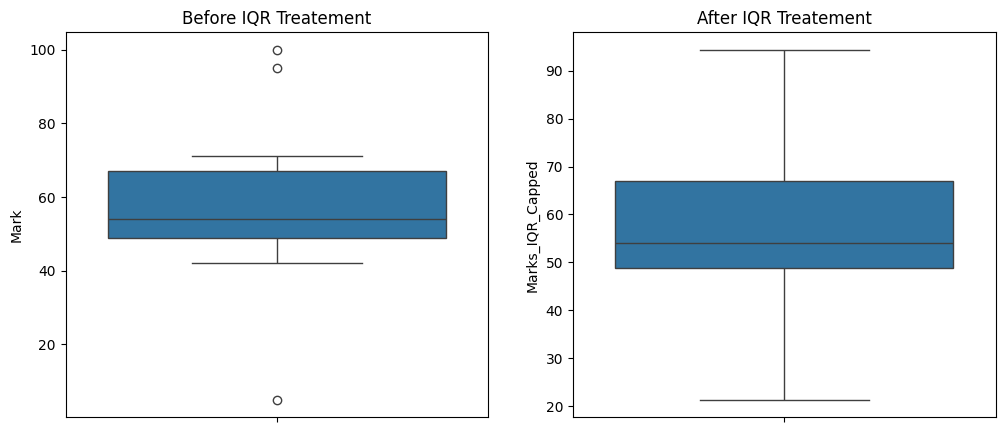

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.boxplot(y=df["Mark"],ax=axes[0])
axes[0].set_title("Before IQR Treatement")
sns.boxplot(y=df["Marks_IQR_Capped"],ax=axes[1])
axes[1].set_title("After IQR Treatement")
plt.show()